In [1]:
%load_ext autoreload
%autoreload 2

## Imports

In [2]:
import geemap
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('use_inf_as_na',True)

import datetime
import pwlf
import numpy as np
import xarray as xr
import rasterio
from pathlib import Path
from tqdm.notebook import tqdm

In [19]:
# Analysis Parameters
imageset = '../data/images_MtPleasant/'
save_image = '../data/min_anom_2021.png'
save_csv = '../data/results_MtPleasant/min_anom_2021.csv'

In [3]:
# get the filenames for all tif files
data_path = Path(imageset) 
file_list = np.array(sorted(list(data_path.glob('*.tif'))))

# an open list to store data array
da_list = []

for filename in file_list:
    date = filename.name.split('T')[0] # get rid of .tif
    date = date[0:4] + '-' + date[4:6] + '-' + date[6:8] # Put into ISO format
    with rasterio.open(filename, 'r') as src:
        im = src.read()
        # read image into ndarray

        # transpose the matrix from (band, row, col) to (row, col, band)
        im = np.transpose(im, [1,2,0])

        # set null values
        im[im == 0.] = np.nan

        # get coordinates
        # first axis, from north to south
        lat_array = np.linspace(src.bounds[3],src.bounds[1],im.shape[0])
        # second axis, from west to east
        lon_array = np.linspace(src.bounds[0],src.bounds[2],im.shape[1])

        src.close()
        
        da = xr.Dataset({'EVI':(('lat','lon'),im[:,:,0]), 'NIRv':(('lat','lon'),im[:,:,1])},
                        coords={'lat':lat_array,'lon':lon_array})
        
        # add time dimension
        da = da.expand_dims('time')
        da.coords['time'] = [np.datetime64(date)]
        
        # append the data array to da_list
        
        da_list.append(da)

In [4]:
all_data = xr.merge(da_list)

In [5]:
all_data

<xarray.Dataset>
Dimensions:  (lat: 76, lon: 117, time: 312)
Coordinates:
  * lat      (lat) float64 4.703e+06 4.703e+06 4.703e+06 ... 4.702e+06 4.702e+06
  * lon      (lon) float64 3.856e+05 3.857e+05 3.857e+05 ... 3.868e+05 3.868e+05
  * time     (time) datetime64[ns] 2018-12-25 2018-12-27 ... 2022-10-30
Data variables:
    EVI      (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan
    NIRv     (time, lat, lon) float64 nan nan nan nan nan ... nan nan nan nan

In [6]:
example = all_data.isel(lat=1, lon=0).to_pandas().reset_index()
example#.dropna()

,time,lat,lon,EVI,NIRv
0,2018-12-25,4.703020e+06,385640.0,NaN,NaN
1,2018-12-27,4.703020e+06,385640.0,NaN,NaN
2,2019-01-14,4.703020e+06,385640.0,NaN,NaN
3,2019-01-21,4.703020e+06,385640.0,NaN,NaN
4,2019-01-26,4.703020e+06,385640.0,NaN,NaN
...,...,...,...,...,...
307,2022-10-10,4.703020e+06,385640.0,NaN,NaN
308,2022-10-15,4.703020e+06,385640.0,NaN,NaN
309,2022-10-22,4.703020e+06,385640.0,NaN,NaN
310,2022-10-25,4.703020e+06,385640.0,NaN,NaN


### Define functions for extracting data from a pixel and fitting seasonal trend

In [7]:
# Extract day of year and year information from system index
def add_doy_year(df):
    safe_df = df.copy()
    
    safe_df['Year'] = safe_df['time'].map(lambda x: x.year)
    safe_df['doy'] = safe_df['time'].map(lambda x: x.timetuple().tm_yday)
    return safe_df

# Normalizes data within year
def normalize_VI(df, band):
    safe_df = df.copy()
    transformed = safe_df[['Year', band]]
    
    safe_df[f'{band}_nrml'] = transformed.groupby(['Year']).transform(lambda x: (x - x.min())/(x.max() - x.min()))[band]
    return safe_df
    
# Removes outliers using a window method
def remove_outliers(df, column):
    safe_df = df.copy()
    
    mean = safe_df[column].mean()
    std = safe_df[column].std()
    safe_df[f'{column}_z_score'] = (safe_df[column] - mean)/std
    
    mask = (safe_df[f'{column}_z_score'] <= 1) & (safe_df[f'{column}_z_score'] >= -1)
    return safe_df[mask]

def window_remove_outliers(df, column, window_column, window_size):
    n = (df[window_column].max() - df[window_column].min()) // window_size
    clean_df = pd.DataFrame()
    
    for i in range(n):
        win_start = i*window_size + df[window_column].min()
        if i == n - 1:
            win_end = df[window_column].max() + 1
        else:
            win_end = (i+1)*window_size + df[window_column].min()
        
        mask = (df[window_column] >= win_start) & (df[window_column] < win_end)
        clean_df = pd.concat([clean_df,remove_outliers(df[mask], column)])
    
    return clean_df

# Duplicate df to have 2 'years' worth of data
def duplicate_doy(df):
    safe_df = df.copy()
    safe_df['doy'] += 365
    
    return pd.concat([df, safe_df])

# Normalize df
def normalize_doy(df, break_guesses):
    safe_df = df.copy()
    safe_df['doy_nrml'] = (safe_df['doy'] - safe_df['doy'].min()) / (safe_df['doy'].max()-safe_df['doy'].min())
    break_guesses = (break_guesses - safe_df['doy'].min()) / (safe_df['doy'].max()-safe_df['doy'].min())
    return safe_df, break_guesses

# Fits a piecewise linear regression to data  
def fit_pwlf(df, break_guesses):
    model = pwlf.PiecewiseLinFit(df['doy'], df['EVI_nrml'])
    model.fit_guess(break_guesses)
    return model

# Calculate defoliation index from anomaly
def calc_defol(df):
    early_mask = (df['doy'] >= 120) & (df['doy'] <= 180) & (df['EVI_anom'] < 0)
    min_early = (df.loc[early_mask])['EVI_anom'].min()
    #mean_early = (df.loc[early_mask])['EVI_anom'].mean()
    
    late_mask = (df['doy'] >= 200) & (df['doy'] <= 250) & (df['EVI_anom'] < 0)
    min_late = (df.loc[late_mask])['EVI_anom'].min()
    #mean_late = (df.loc[late_mask])['EVI_anom'].mean()
    # Method 1:
    # return (min_late-.25)/min_early
    
    # Method 2:
    # return min_early*min_late + min_early*min_early
    
    # Method 3:
    return (np.abs(min_early) - np.abs(min_late))/(np.abs(min_early) + np.abs(min_late))
    
    # Method 4:
    # return ((np.abs(min_early) - np.abs(min_late))/(np.abs(min_early) + np.abs(min_late))) * (1 - np.abs(min_late))
    
    # Method 5:
    #return (np.abs(mean_early) - np.abs(mean_late))/(np.abs(mean_early) + np.abs(mean_late))

In [8]:
def process_point(dataset, latitude, longitude):
    # Paramters for analysis
    band = 'EVI'
    
    df = dataset.isel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    if len(df) == 0:
        return np.nan
    
    # Extract day of year and year information from system index
    df = add_doy_year(df)
    
    year_mask = df['Year'] >= 2019
    df = df.loc[year_mask]
    
    # Normalizes data within year
    df = normalize_VI(df, band)
    
    # Removes outliers using a window method
    df = window_remove_outliers(df, band, 'doy', 15)
    
    #break_guesses = np.array()
    
    # Normalize doy
    #df, break_guesses = normalize_doy(df, break_guesses)
    
    # Duplicate df to have 2 'years' worth of data
    df = duplicate_doy(df)
    
    # Fits a piecewise linear regression to data
    #try:
    model = fit_pwlf(df, [120, 150, 275, 310, 490, 540, 650])
    #except:
    #    return -1000
    
    # Calculate anomaly
    df['EVI_pred'] = model.predict(df['doy'])
    df['EVI_anom'] = df['EVI_nrml'] - df['EVI_pred']
    
    # Record maximum anomaly for 2021
    mask = (df['Year'] == 2021)
    #return calc_defol(df.loc[mask])
    return (df.loc[mask])['EVI_anom'].min()

In [9]:
defol = pd.DataFrame(columns = ['lat', 'lon', 'EVI'])
x_length = all_data.sizes['lon']
y_length = all_data.sizes['lat']


with tqdm(total = x_length*y_length) as pbar:
    for y in range(y_length):
        for x in range(x_length):
            evi = process_point(all_data, y, x)
            defol.loc[len(defol.index)] = [y, x, evi]
            pbar.update(1)

  0%|          | 0/8892 [00:00<?, ?it/s]

In [15]:
mask = (defol['EVI'] < 1000)# & (defol['EVI'] > -0.4)
#(defol.loc[mask])['EVI'] == np.nan
defol_pivot = (defol.loc[mask]).pivot(index = 'lat', columns = 'lon')

In [16]:
defol_pivot

EVI                                                              \
lon      0.0       1.0       2.0       3.0       4.0       5.0       6.0     
lat                                                                          
0.0        NaN -0.090215 -0.100056 -0.144122 -0.111486 -0.162044 -0.241887   
1.0        NaN -0.101540 -0.101947 -0.113719 -0.497765 -0.456619 -0.105292   
2.0        NaN -0.173419 -0.163730 -0.558212 -0.479392 -0.517657 -0.097815   
3.0        NaN -0.176679 -0.147448 -0.486202 -0.455146 -0.502684 -0.555973   
4.0        NaN -0.146514 -0.223251 -0.413029 -0.358147 -0.309985 -0.343767   
...        ...       ...       ...       ...       ...       ...       ...   
70.0 -0.103467 -0.091373 -0.087179 -0.090946 -0.092209 -0.431099 -0.232410   
71.0 -0.144587 -0.119981 -0.144634 -0.106748 -0.130565 -0.115362 -0.091577   
72.0 -0.203514 -0.132530 -0.114743 -0.116698 -0.160763 -0.110359 -0.115736   
73.0 -0.129640 -0.132838 -0.144361 -0.139681 -0.132219 -0.130749 -0.119981   
74.0       NaN       NaN       NaN       NaN       NaN       NaN       NaN   

                                    ...                                \
lon      7.0       8.0       9.0    ...     107.0     108.0     109.0   
lat                                 ...                                 
0.0  -0.171948 -0.124215 -0.412377  ...       NaN       NaN       NaN   
1.0  -0.163661 -0.104945 -0.398578  ...       NaN       NaN       NaN   
2.0  -0.082625 -0.107831 -0.081585  ... -0.103320 -0.135915 -0.178550   
3.0  -0.075611 -0.097722 -0.107717  ... -0.084451 -0.111303 -0.152113   
4.0  -0.434291 -0.444608 -0.360862  ... -0.093850 -0.105168 -0.136245   
...        ...       ...       ...  ...       ...       ...       ...   
70.0 -0.159154 -0.120475 -0.111540  ... -0.478726 -0.449033 -0.475661   
71.0 -0.175520 -0.105387 -0.202576  ... -0.518387 -0.474324 -0.465194   
72.0 -0.179984 -0.157126 -0.167912  ... -0.521037 -0.495137 -0.487850   
73.0 -0.090903 -0.264079 -0.198339  ... -0.138875 -0.475769 -0.496976   
74.0       NaN       NaN       NaN  ... -0.141440 -0.104008 -0.480325   

                                                                            
lon      110.0     111.0     112.0     113.0     114.0     115.0     116.0  
lat                                                                         
0.0        NaN       NaN       NaN       NaN       NaN       NaN       NaN  
1.0        NaN       NaN       NaN       NaN       NaN       NaN       NaN  
2.0  -0.114063 -0.118605 -0.083254 -0.161280 -0.137496 -0.118159 -0.134920  
3.0  -0.168775 -0.125882 -0.136474 -0.106413 -0.130362 -0.128759 -0.161363  
4.0  -0.118920 -0.104780 -0.116616 -0.104300 -0.160619 -0.158934 -0.166864  
...        ...       ...       ...       ...       ...       ...       ...  
70.0 -0.502909 -0.529108 -0.531628 -0.478026 -0.121839 -0.148040       NaN  
71.0 -0.471956 -0.468681 -0.507212 -0.141551 -0.177547 -0.128399       NaN  
72.0 -0.476595 -0.474143 -0.123532 -0.113740 -0.070970 -0.101728       NaN  
73.0 -0.501361 -0.503440 -0.090277 -0.110558 -0.066230 -0.081030       NaN  
74.0 -0.473801 -0.511797 -0.524726 -0.187153 -0.167758 -0.498754       NaN  

[75 rows x 117 columns]

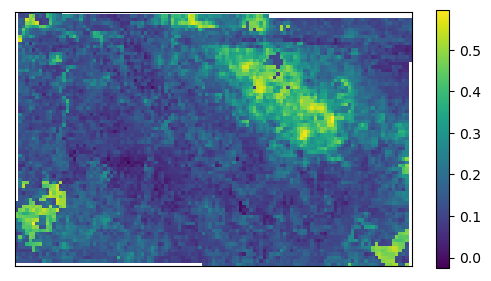

In [17]:

plt.imshow(defol_pivot * -1)
plt.colorbar(shrink = 0.7)
plt.xticks([])
plt.yticks([])
plt.savefig(save_image)

In [18]:
defol.to_csv(save_csv)

In [14]:
df

NameError: name 'df' is not defined

In [ ]:
all_data.isel(lat=50, lon=50).to_pandas().reset_index()

In [ ]:
# Paramters for analysis
band = 'EVI'
latitude = 50
longitude = 50
    
df = all_data.isel(lat=latitude, lon=longitude).to_pandas().reset_index().dropna()
    
# Extract day of year and year information from system index
df = add_doy_year(df)

year_mask = df['Year'] >= 2019
df = df.loc[year_mask]

# Normalizes data within year
df = normalize_VI(df, band)
    
# Removes outliers using a window method
#df = window_remove_outliers(df, band, 'doy', 15)
    
#break_guesses = np.array()
    
# Normalize doy
#df, break_guesses = normalize_doy(df, break_guesses)
    
# Duplicate df to have 2 'years' worth of data
df = duplicate_doy(df)

In [ ]:
mask = df['EVI_nrml'].isna()
df.loc[mask]

In [ ]:
mask = df['doy'] <=365

plt.plot((df.loc[mask])['doy'], (df.loc[mask])['EVI_nrml'], 'o')

In [ ]:
model = fit_pwlf(df, [120, 150, 275, 310, 490, 540, 650])

In [ ]:
X_grid = np.linspace(df['doy'].min(), df['doy'].max(), 100)
y_pred = model.predict(X_grid)

plt.plot(df['doy'], df['EVI_nrml'], 'o')
plt.plot(X_grid, y_pred)

In [ ]:
defol